In [1]:
import torchgeo
import torchgeo.models
import torchgeo.datasets

#import planetary_computer
#from pystac import Item
import requests
import os
from urllib.parse import unquote
from torchgeo.samplers import RandomGeoSampler, GridGeoSampler
from torchgeo.samplers.constants import Units
from torchgeo.datasets import RasterDataset, Sentinel2, stack_samples
from tqdm import tqdm
import requests
import os
from urllib.parse import unquote
from typing import Optional, Sequence
import numpy as np

import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import sklearn
import sklearn.metrics

/n/home10/erolf/.conda/envs/siml_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# get sentinel data

In [3]:
data_dir = 'data'

In [4]:

sentinel_data_dir = data_dir + "/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704"

sentinel = Sentinel2(
    sentinel_data_dir,
    bands=["B02", # blue
           "B03", # green
           "B04", # red
           "B08", # NIR
           "TCI"
          ] 
)

In [5]:
nir_band = 3
label_band = 7
vis_band_start = 4
vis_band_end = 7

def my_transforms(sample):
    
    sample['image'][0] = (sample['image'][0] - 1400.) / 60.
    sample['image'][1] = (sample['image'][1] - 1600.) / 60.
    sample['image'][2] = (sample['image'][2] - 1600.) / 120.
    
    sample['image'][nir_band] = (sample['image'][nir_band] - 3000.) / 300.
    return sample

In [9]:
def make_site_dataset(eval_site, sentinel_dataset, transforms, data_dir=data_dir):
    
    print(eval_site)
    chm_dataset = RasterDataset(root=data_dir + f'/lidar/Karingani_merged_crs_10/site_{eval_site}')
    ds = torchgeo.datasets.IntersectionDataset(sentinel_dataset, chm_dataset, transforms=transforms)
    return ds

def eval_existing_dataproduct(ds_eval, 
                              chip_size,
                              pad,
                              tile_shape
                              ):
    bs_eval=1
    patch_size = (chip_size-2*pad)
    
    eval_sampler = GridGeoSampler(ds_eval, size=chip_size, stride=patch_size, units=Units.PIXELS)
    eval_dataloader = DataLoader(ds_eval, batch_size=bs_eval, sampler=eval_sampler, collate_fn=stack_samples)

    ps = patch_size
    output_shape = [x * patch_size for x in tile_shape]
    ref_ = np.zeros(output_shape)
    labels_ = np.zeros(output_shape)
    vis_ = np.zeros([3] + output_shape )

    with torch.no_grad():
        for i, sample in enumerate(eval_dataloader):
            # Again using Caleb code :)
            with torch.inference_mode():
                data = sample["image"]
                bbox = sample["bbox"]
                ref = data[:,label_band+1:label_band+2,pad:-pad,pad:-pad]
                labels= data[:,label_band:label_band+1,pad:-pad,pad:-pad]
                vis = data[:,vis_band_start:vis_band_end,pad:-pad,pad:-pad]

                yi = i % tile_shape[0] 
                xi = 8 - i // tile_shape[0] 
                ref_[xi*ps:(xi+1)*ps, yi*ps:(yi+1)*ps] = ref[0][0]
                labels_[xi*ps:(xi+1)*ps, yi*ps:(yi+1)*ps] = labels[0]
                vis_[:,xi*ps:(xi+1)*ps, yi*ps:(yi+1)*ps] = vis[0]

    return {'preds': ref_, 'labels':labels_, 'vis': vis_}

def eval_existing_product(eval_site,
                          dataproduct_path,
                          sentinel,
                          plot_scatter='True',
                          plot_prediction_map='True'):
    
    chip_size = 64
    pad = 5
    tile_shape = (9,9)
    
    print(eval_site)
    ds_ours = make_site_dataset(eval_site, 
                                sentinel_dataset=sentinel, 
                                transforms=my_transforms)
    
    ref_ds = RasterDataset(root=dataproduct_path)
    ds_eval = torchgeo.datasets.IntersectionDataset(ds_ours, ref_ds, transforms=my_transforms)


    output = eval_existing_dataproduct(ds_eval, 
                                   chip_size=chip_size,
                                   pad=pad,
                                   tile_shape=tile_shape)

    preds_ = output['preds']
    labels_ = output['labels']
    vis_ = output['vis']
    mask = labels_ > 0
    
    r2 = sklearn.metrics.r2_score(labels_[mask],preds_[mask])
    mae = sklearn.metrics.mean_absolute_error(labels_[mask],preds_[mask])
    mse = sklearn.metrics.mean_squared_error(labels_[mask],preds_[mask])
    if plot_scatter:
        plt.scatter(labels_[mask],preds_[mask], alpha=0.1)
        plt.title(f'R2: {r2:.2f}, MAE: {mae:.2f}')
    if plot_prediction_map:
        fig, ax = plt.subplots(1,3, figsize=(18*4,6*4))
        ymax = labels_.max()
        ax[0].imshow(labels_, vmin=0, vmax=ymax, cmap='Greens')
        preds_show = preds_.copy()

        mask = labels_ > 0
        preds_show[~mask] = 0
        ax[1].imshow(preds_show, vmin=0, vmax=ymax, cmap='Greens')
        ax[2].imshow(vis_.transpose(1,2,0).astype(int))
    return {'r2':r2, 'mae':mae, 'mse':mse}

In [10]:
eth_path = data_dir + f'/int/global_tch_maps/eth'

6
6
Converting RasterDataset resolution from 9.995824634655532 to 10
13
13
Converting RasterDataset resolution from 10.004158004158004 to 10
14
14
Converting RasterDataset resolution from 10.006263048016702 to 10


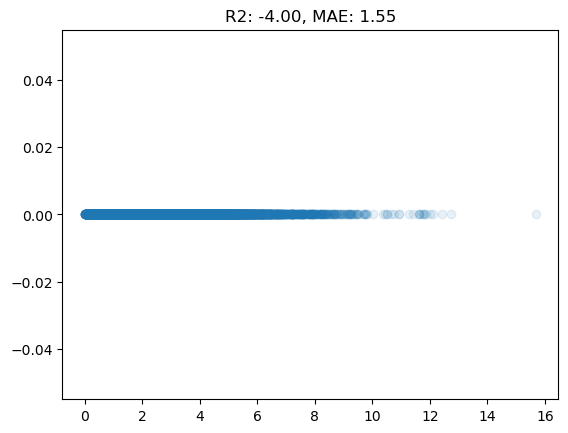

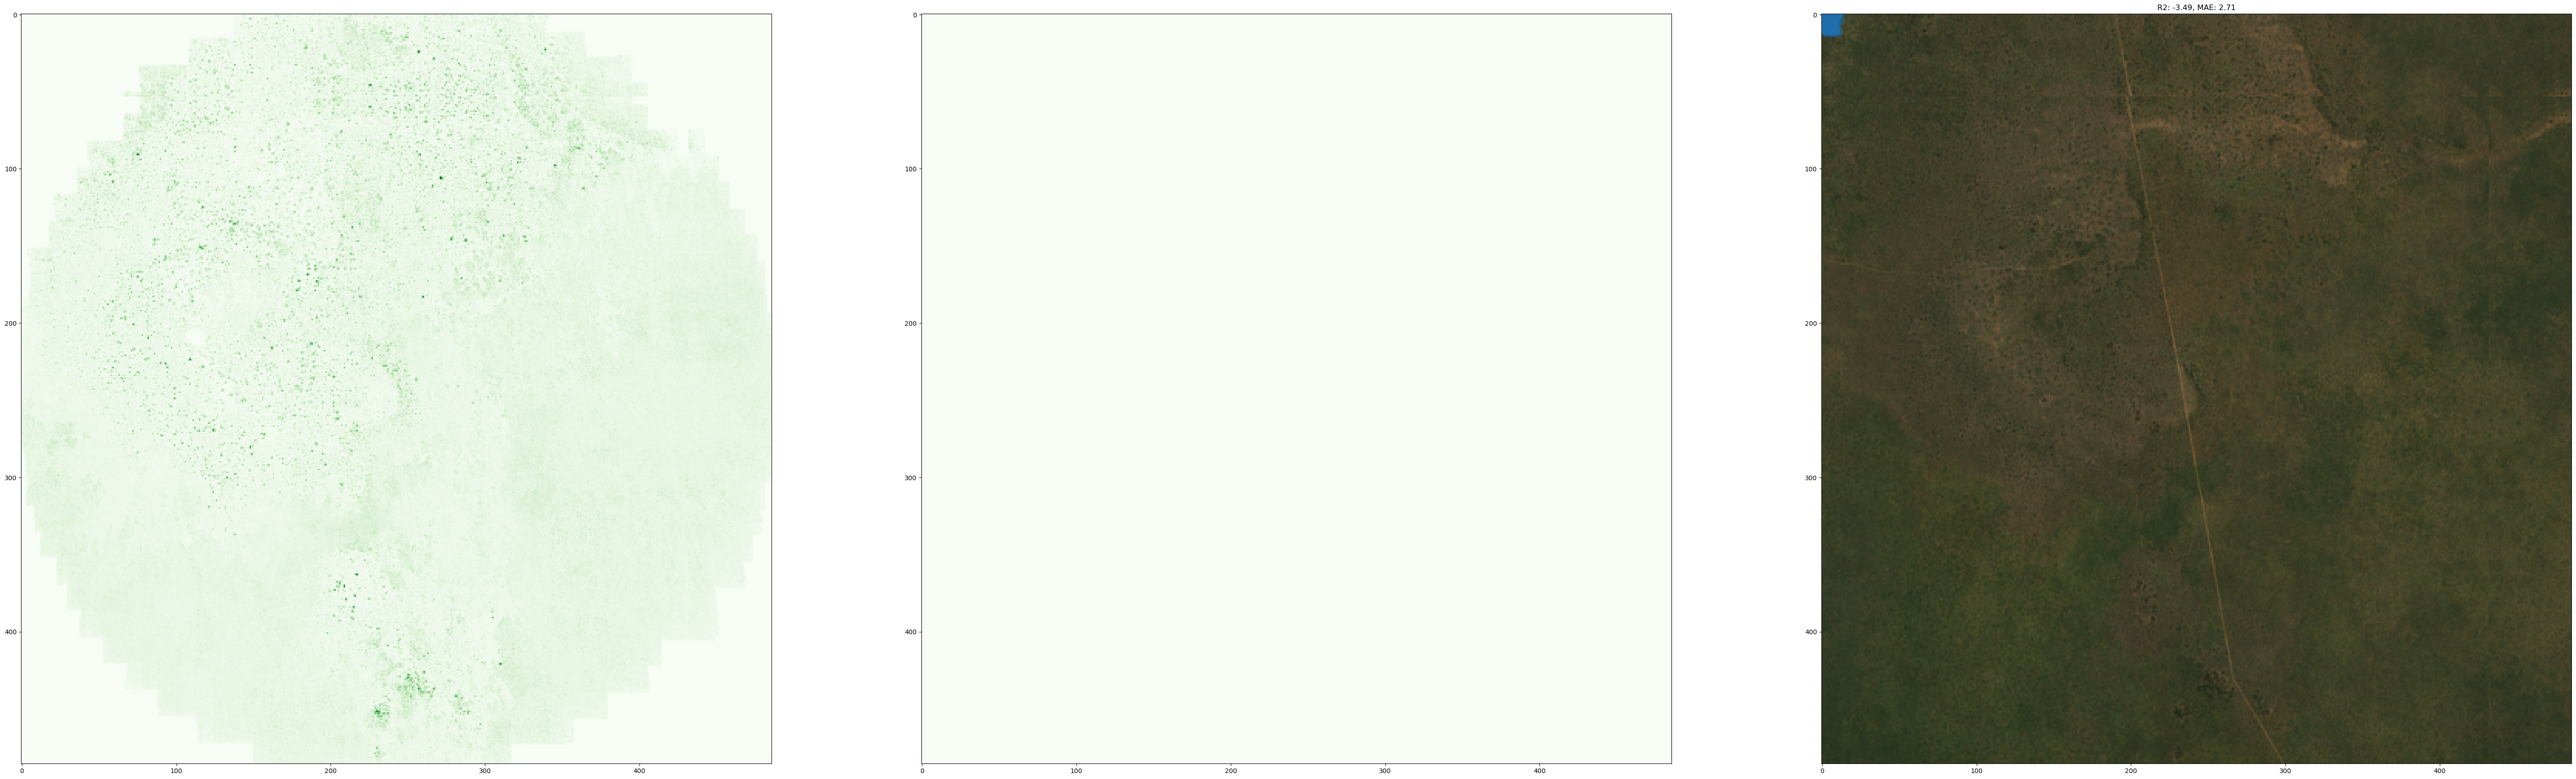

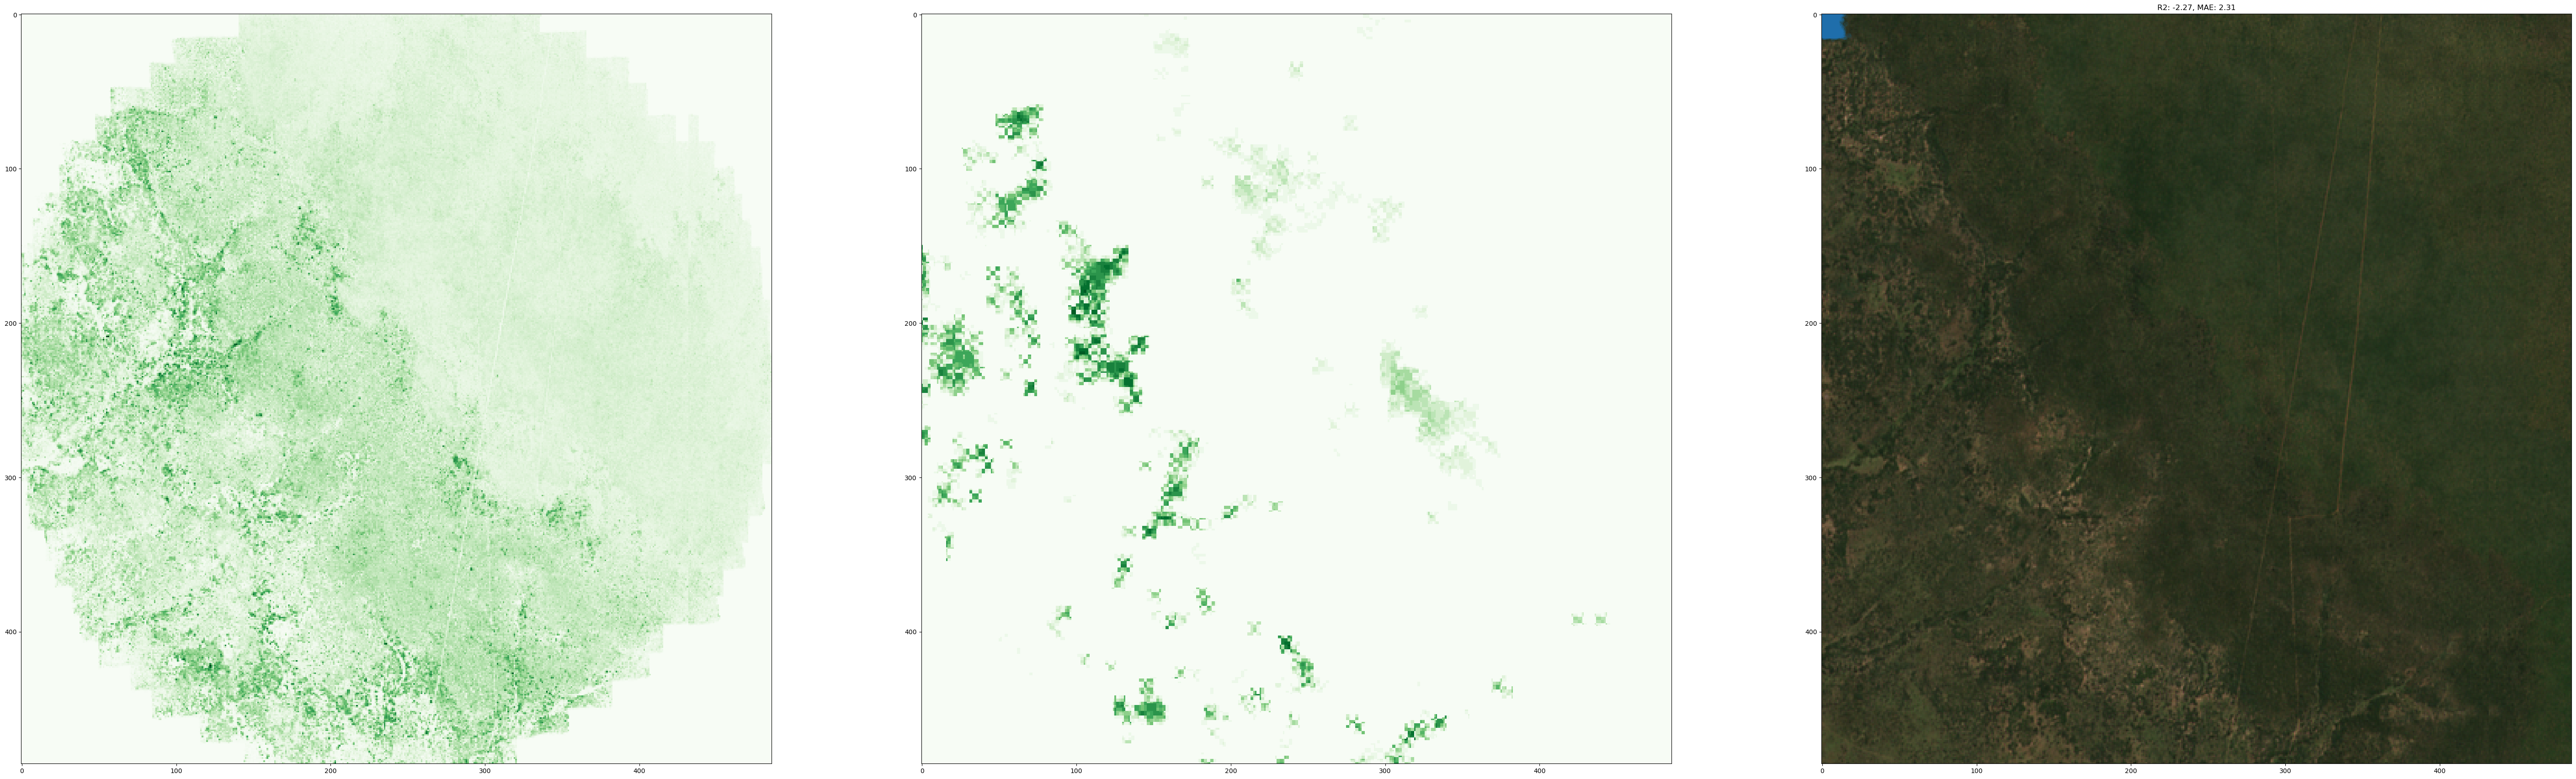

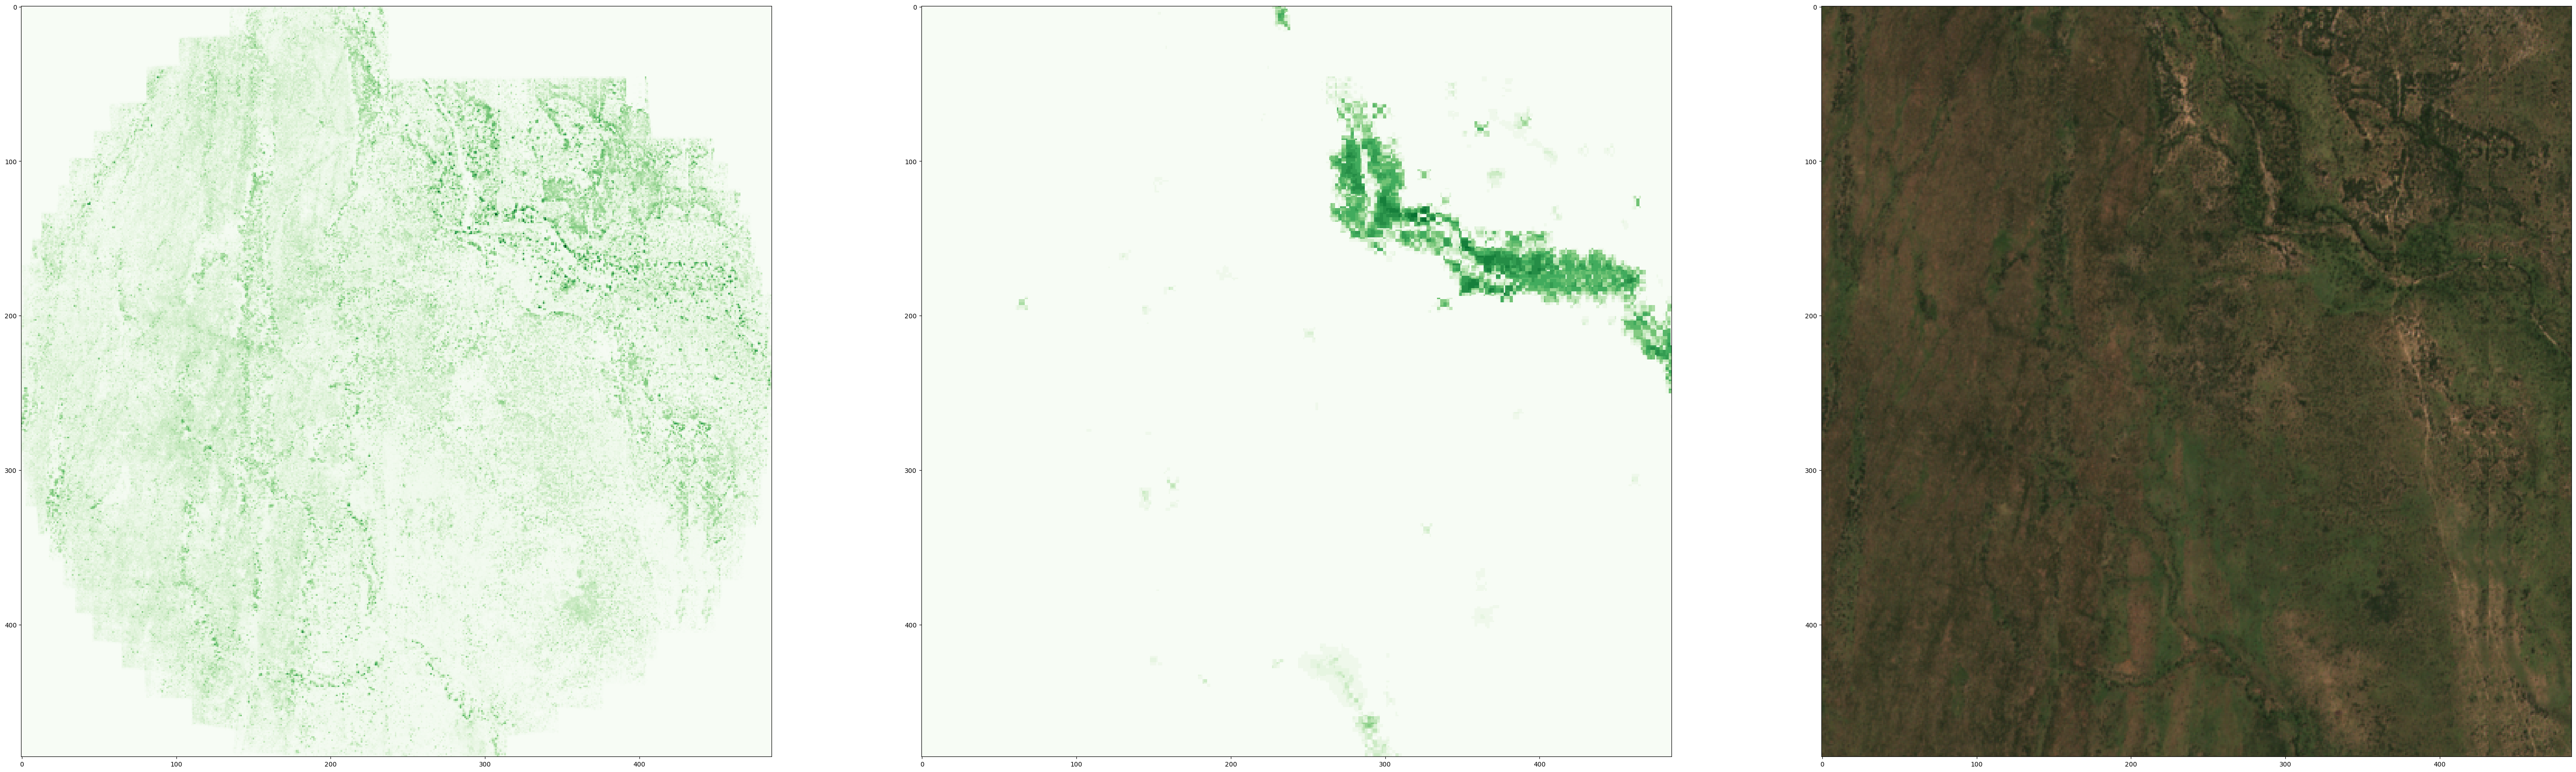

In [20]:
eval_site_ids = [6,13,14]
res_by_site = []
for eval_site_id in eval_site_ids:

    res = eval_existing_product(eval_site_id, 
                      eth_path,
                     sentinel)
    
    res_by_site.append(res)

In [21]:
res_by_site

[{'r2': -4.001514761660555,
  'mae': 1.553971709228416,
  'mse': 3.0183065598341803},
 {'r2': -3.4870224477364973,
  'mae': 2.7080041489102267,
  'mse': 9.437547629249586},
 {'r2': -2.268671571343265,
  'mae': 2.3126403052554667,
  'mse': 8.372454954223423}]